In [ ]:
from google.colab import files
uploaded = files.upload()

Saving DL_Dataset_Project_YoLo.zip to DL_Dataset_Project_YoLo.zip


In [ ]:
!pip install -q ultralytics

import os
import zipfile
import shutil
import random
from glob import glob
import yaml
from ultralytics import YOLO

zip_path = "DL_Dataset_Project_YoLo.zip"
extract_path = "/content/vehicle-dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"✅ Dataset unzipped to ➜ {extract_path}")

image_paths = glob(os.path.join(extract_path, "**", "*.jpg"), recursive=True)
valid_pairs = []

for img_path in image_paths:
    label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")
    if os.path.exists(label_path):
        valid_pairs.append((img_path, label_path))

print(f"✅ Found {len(valid_pairs)} valid image-label pairs")

random.shuffle(valid_pairs)
split_index = int(0.8 * len(valid_pairs))
train_data = valid_pairs[:split_index]
valid_data = valid_pairs[split_index:]

def copy_to_folder(pairs, split):
    img_folder = os.path.join(extract_path, split, "images")
    lbl_folder = os.path.join(extract_path, split, "labels")
    os.makedirs(img_folder, exist_ok=True)
    os.makedirs(lbl_folder, exist_ok=True)

    for img_src, lbl_src in pairs:
        img_dst = os.path.join(img_folder, os.path.basename(img_src))
        lbl_dst = os.path.join(lbl_folder, os.path.basename(lbl_src))

        if os.path.abspath(img_src) != os.path.abspath(img_dst):
            shutil.copy(img_src, img_dst)
        if os.path.abspath(lbl_src) != os.path.abspath(lbl_dst):
            shutil.copy(lbl_src, lbl_dst)

copy_to_folder(train_data, "train")
copy_to_folder(valid_data, "valid")

print("✅ Dataset structured successfully into /train and /valid folders")

class_names = ['car', 'bus', 'truck']

data_yaml = {
    'train': os.path.join(extract_path, 'train/images'),
    'val': os.path.join(extract_path, 'valid/images'),
    'nc': len(class_names),
    'names': class_names
}

with open("vehicle.yaml", "w") as f:
    yaml.dump(data_yaml, f)

print("✅ vehicle.yaml created!")

model = YOLO('yolov8s.pt')

results = model.train(
    data='vehicle.yaml',
    epochs=20,
    imgsz=640,
    batch=16,
    name='vehicle_yolov8_project'
)

print("✅ YOLOv8 training complete!")

✅ Dataset unzipped to ➜ /content/vehicle-dataset
✅ Found 913 valid image-label pairs
✅ Dataset structured successfully into /train and /valid folders
✅ vehicle.yaml created!
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=vehicle.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum

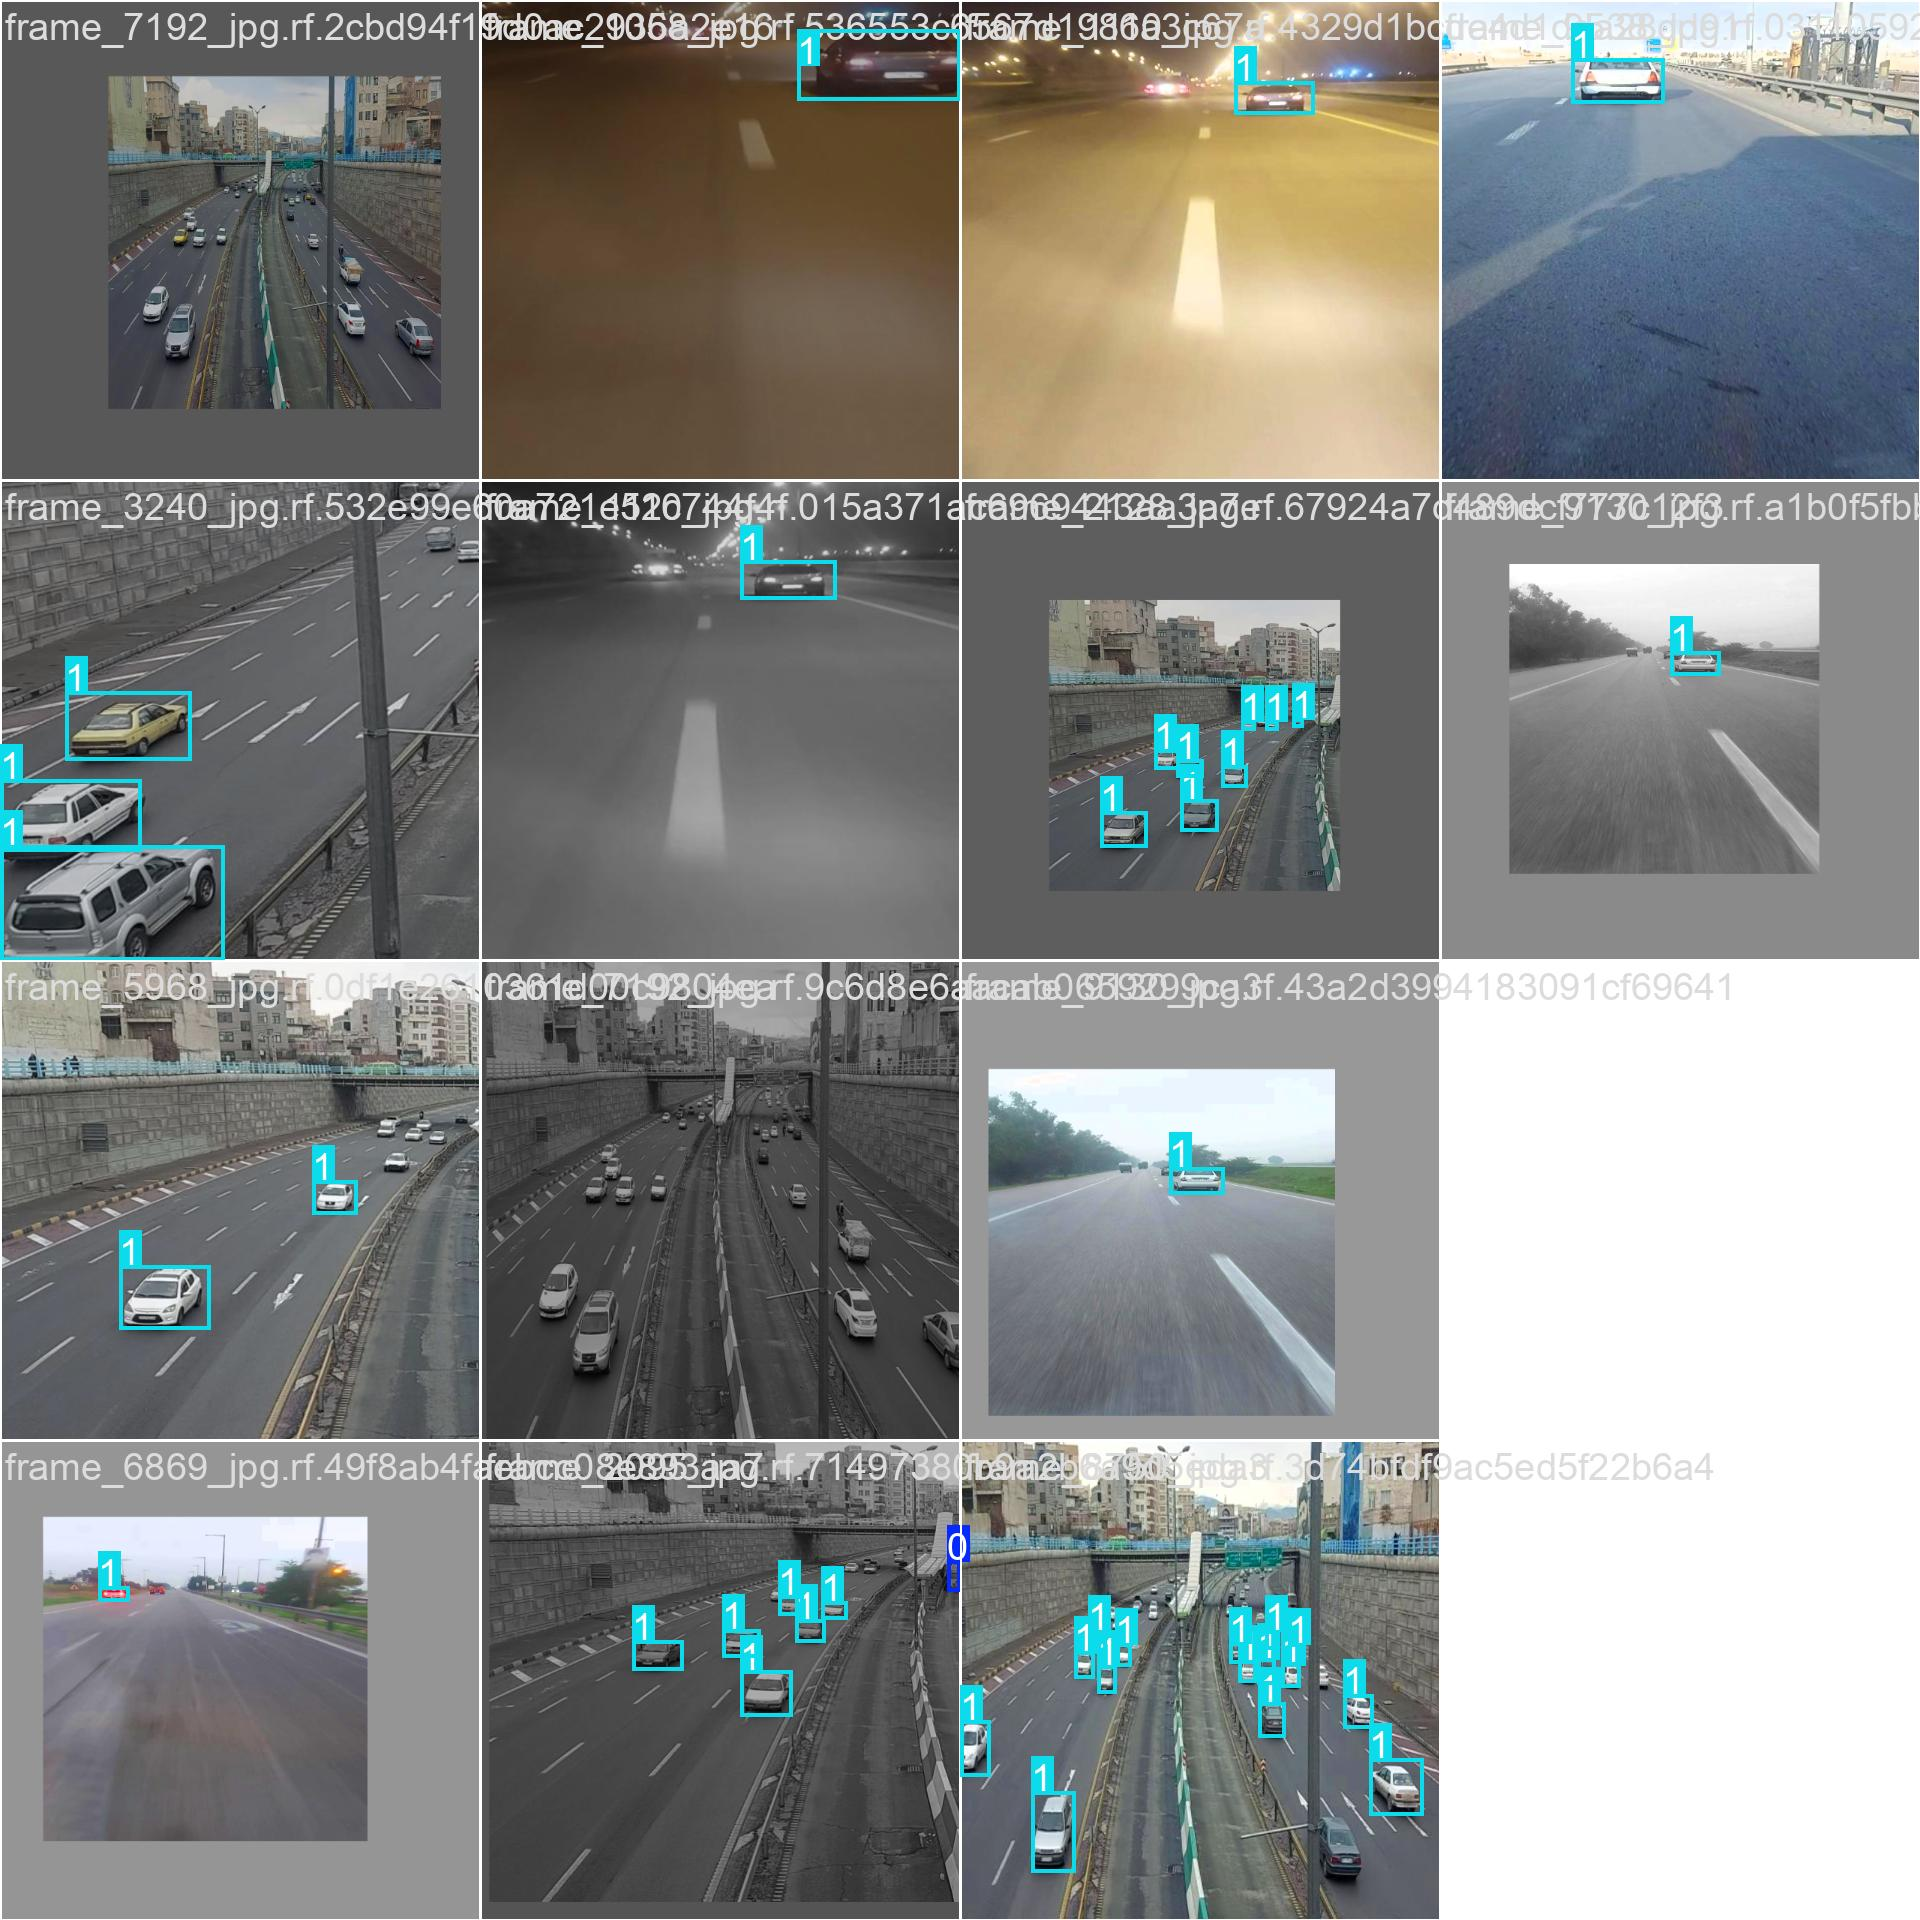

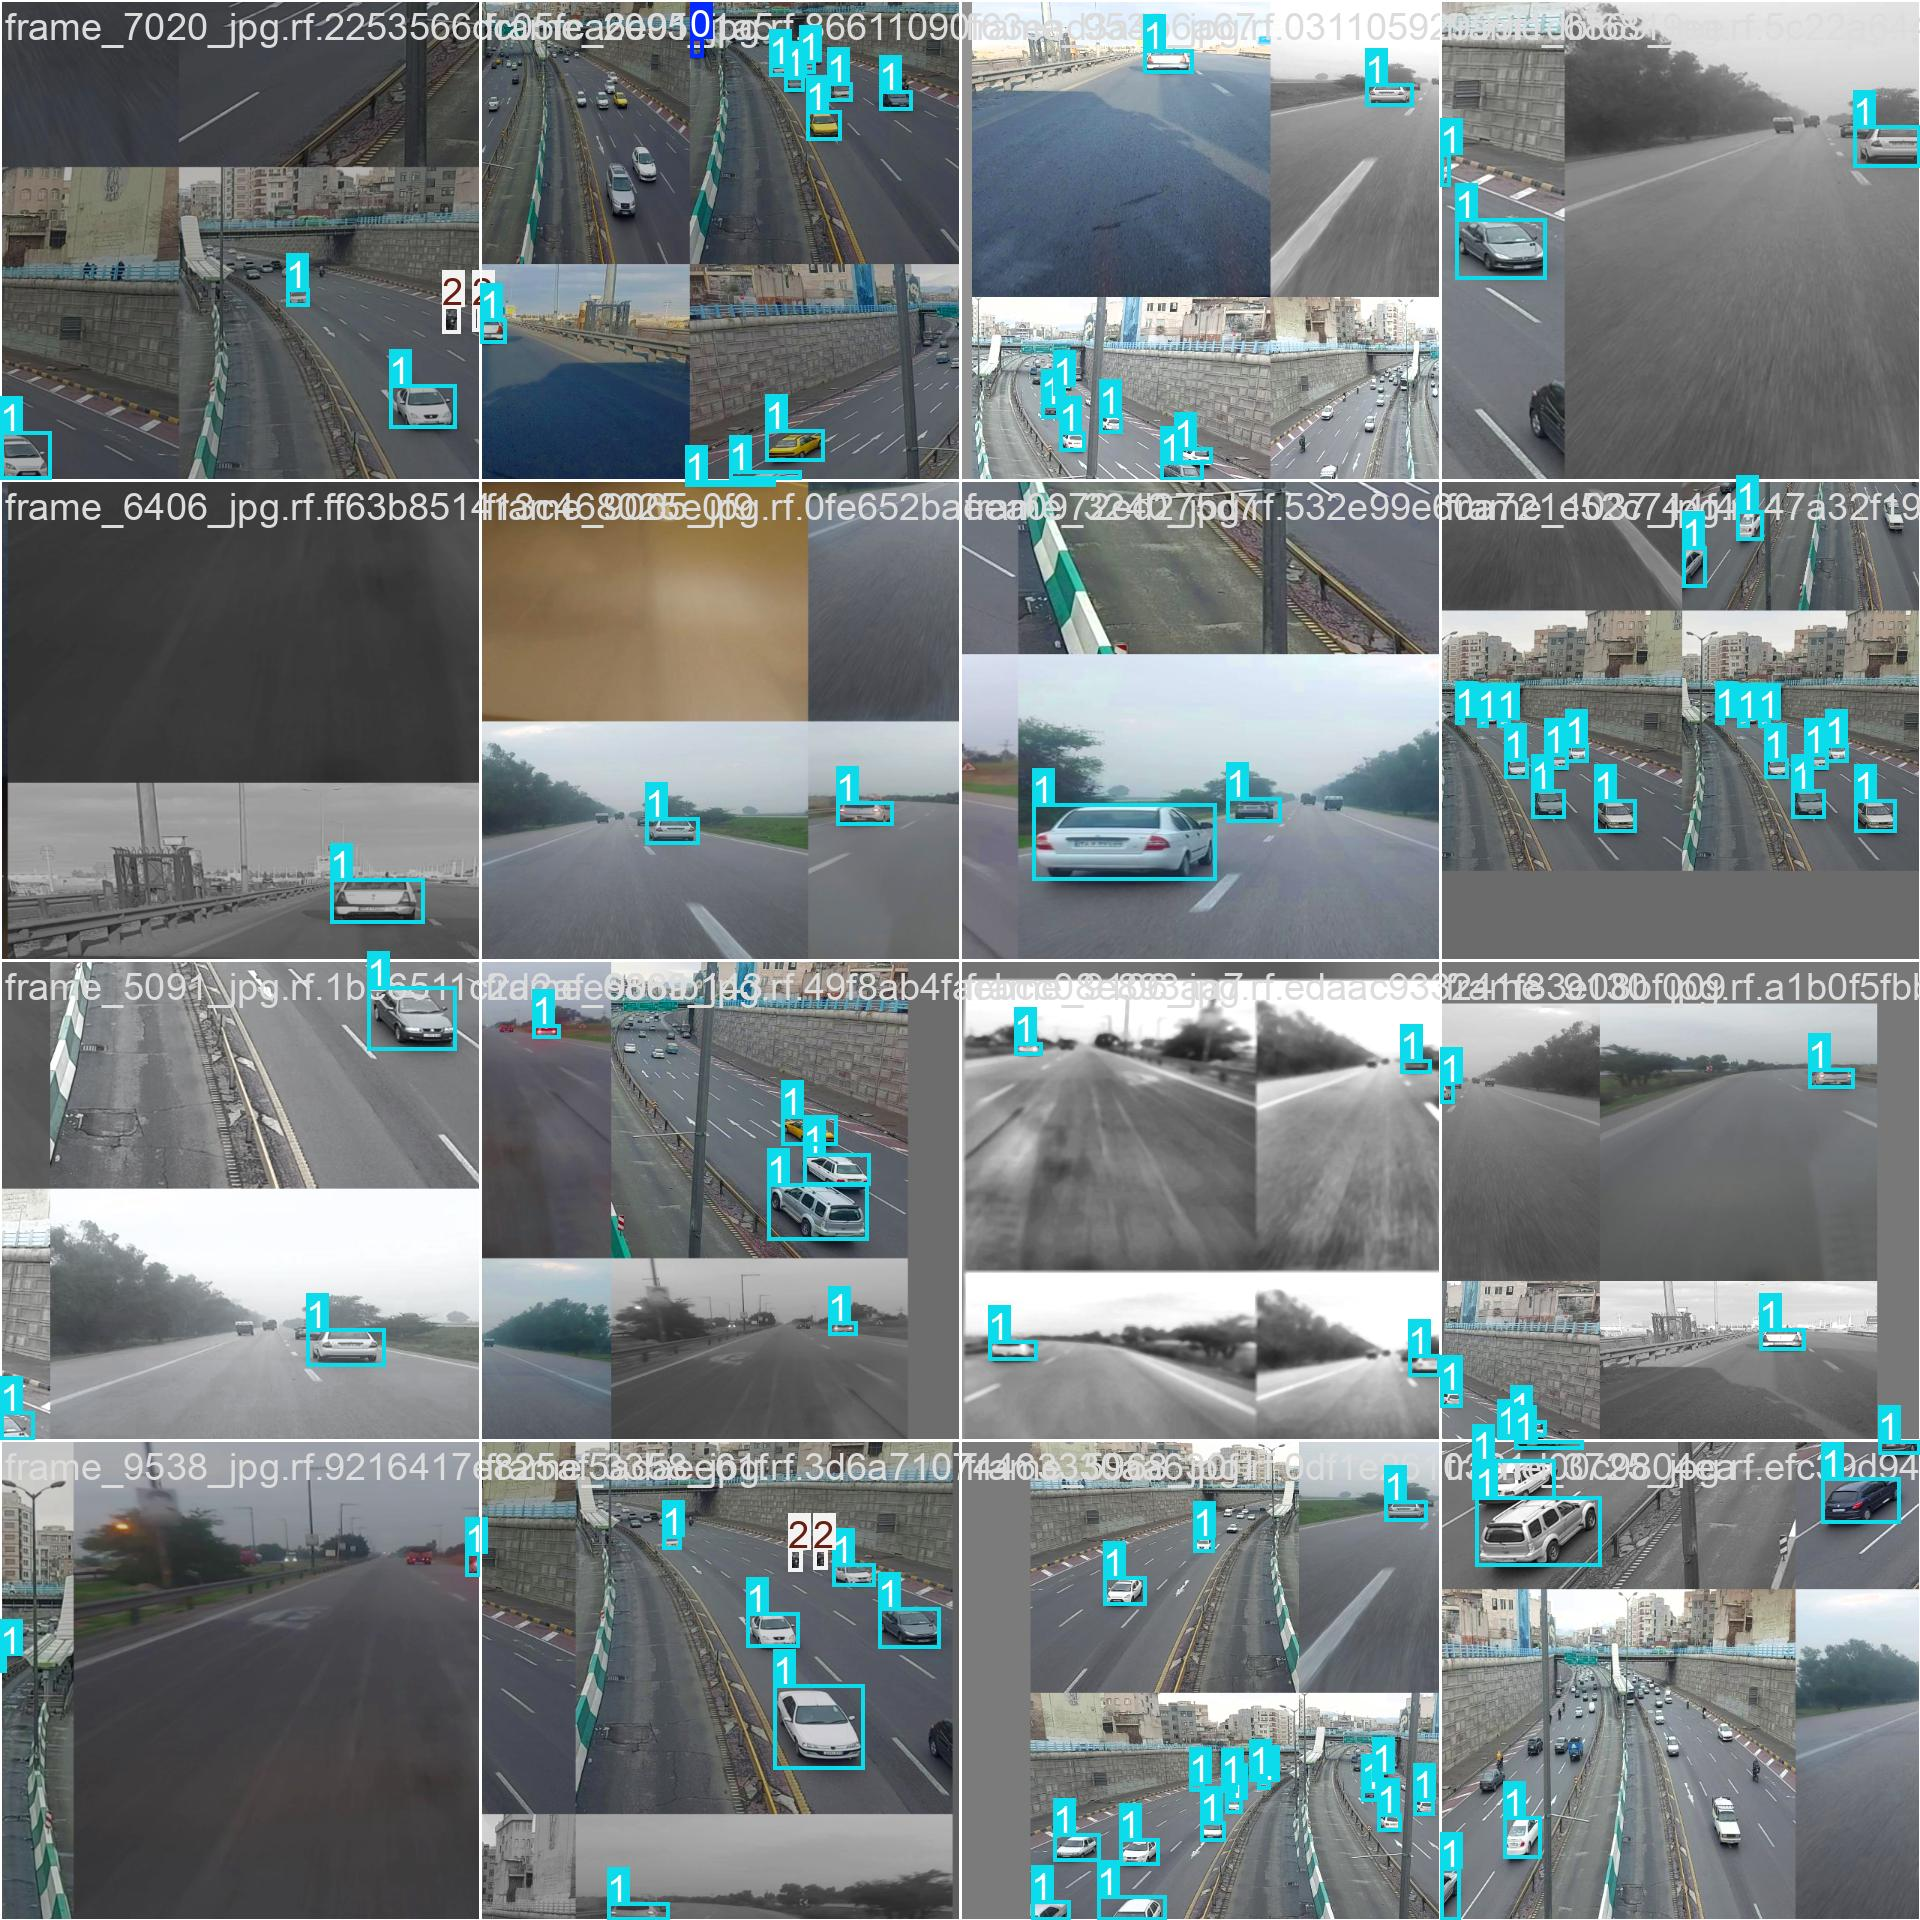

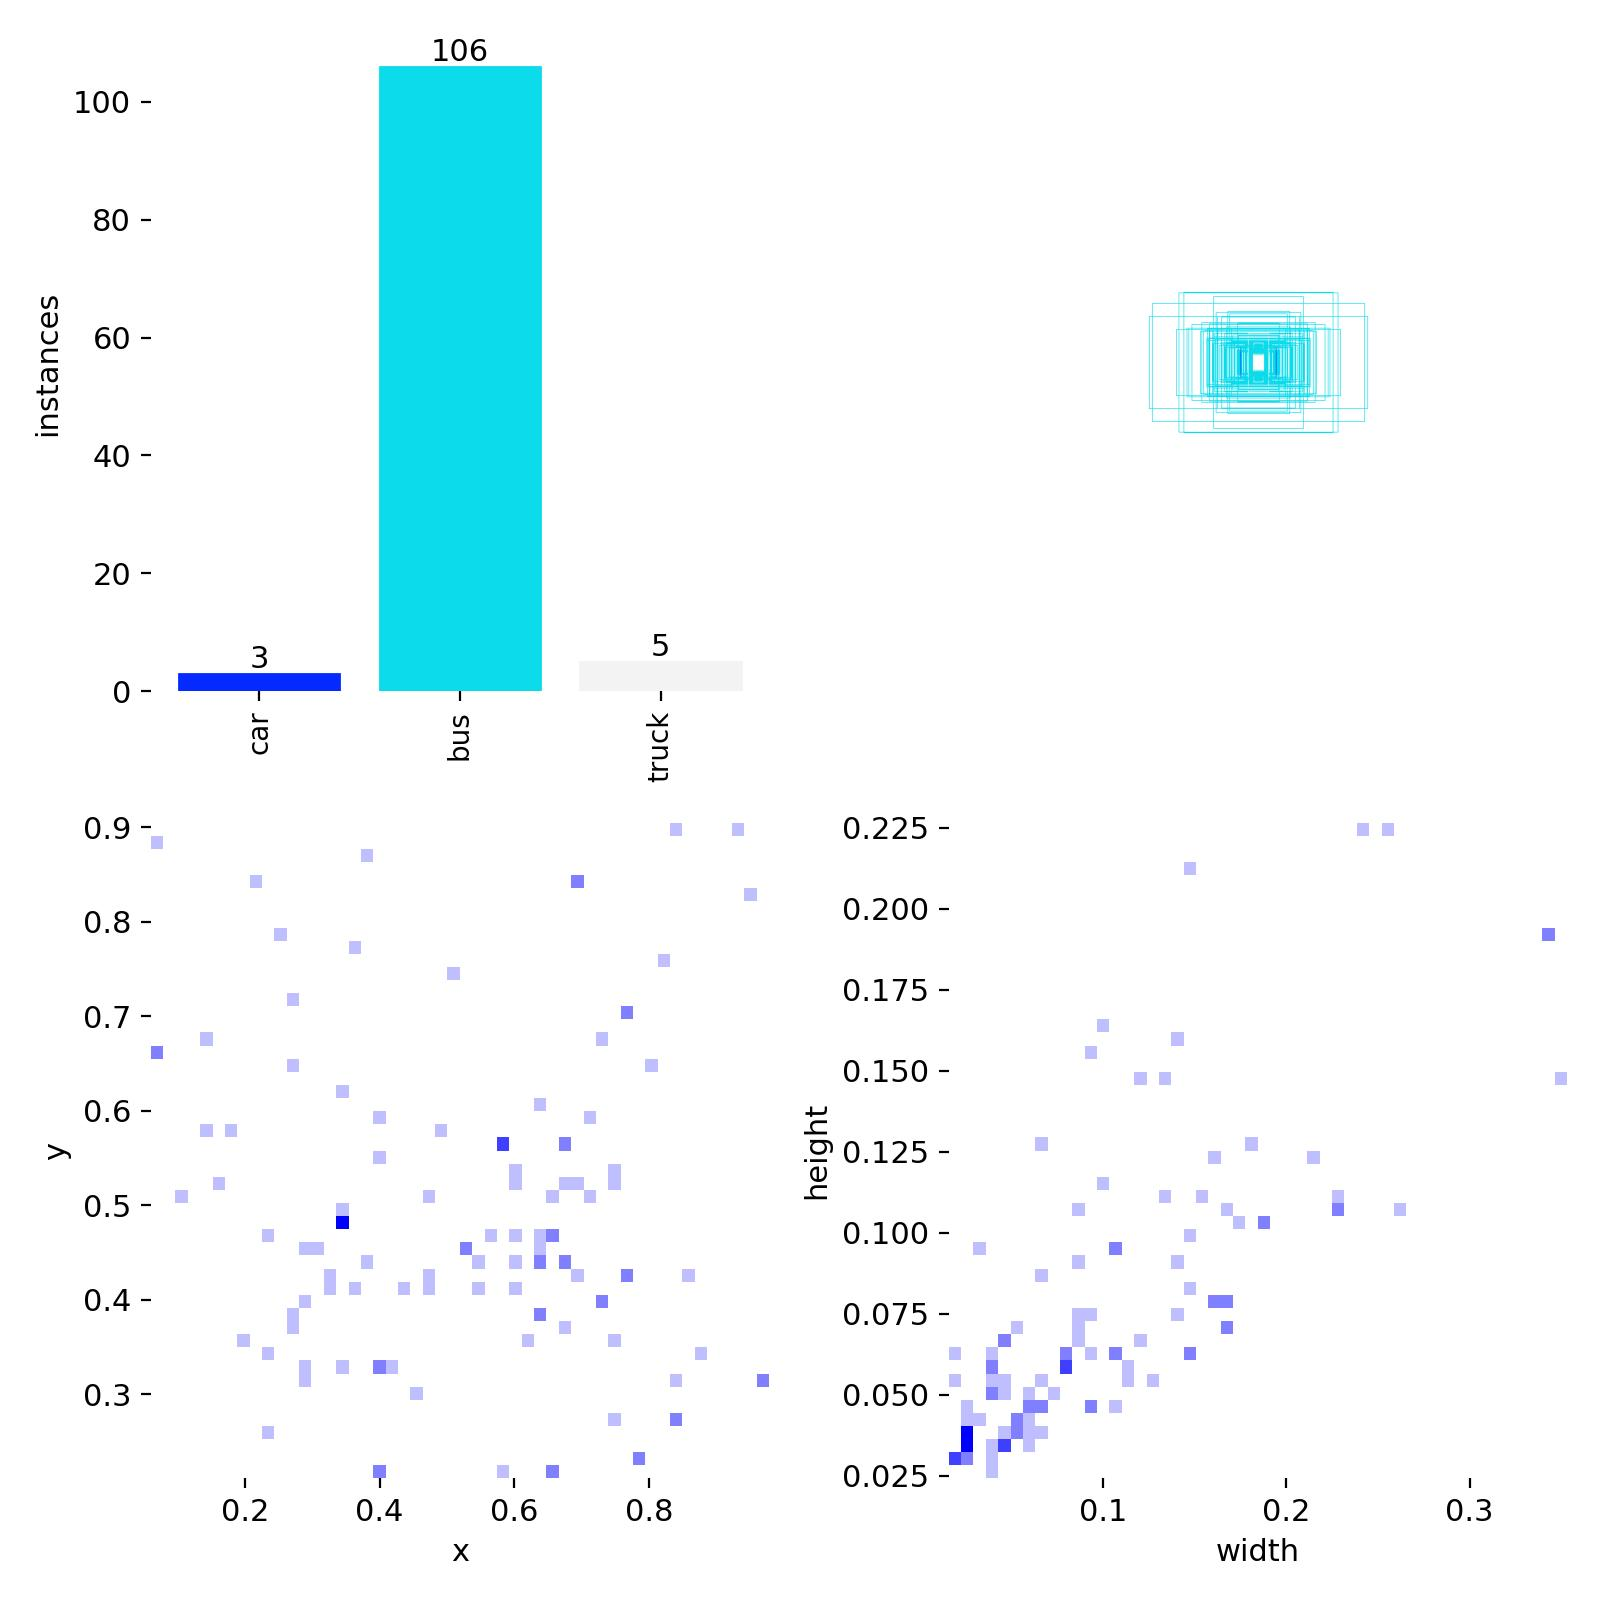

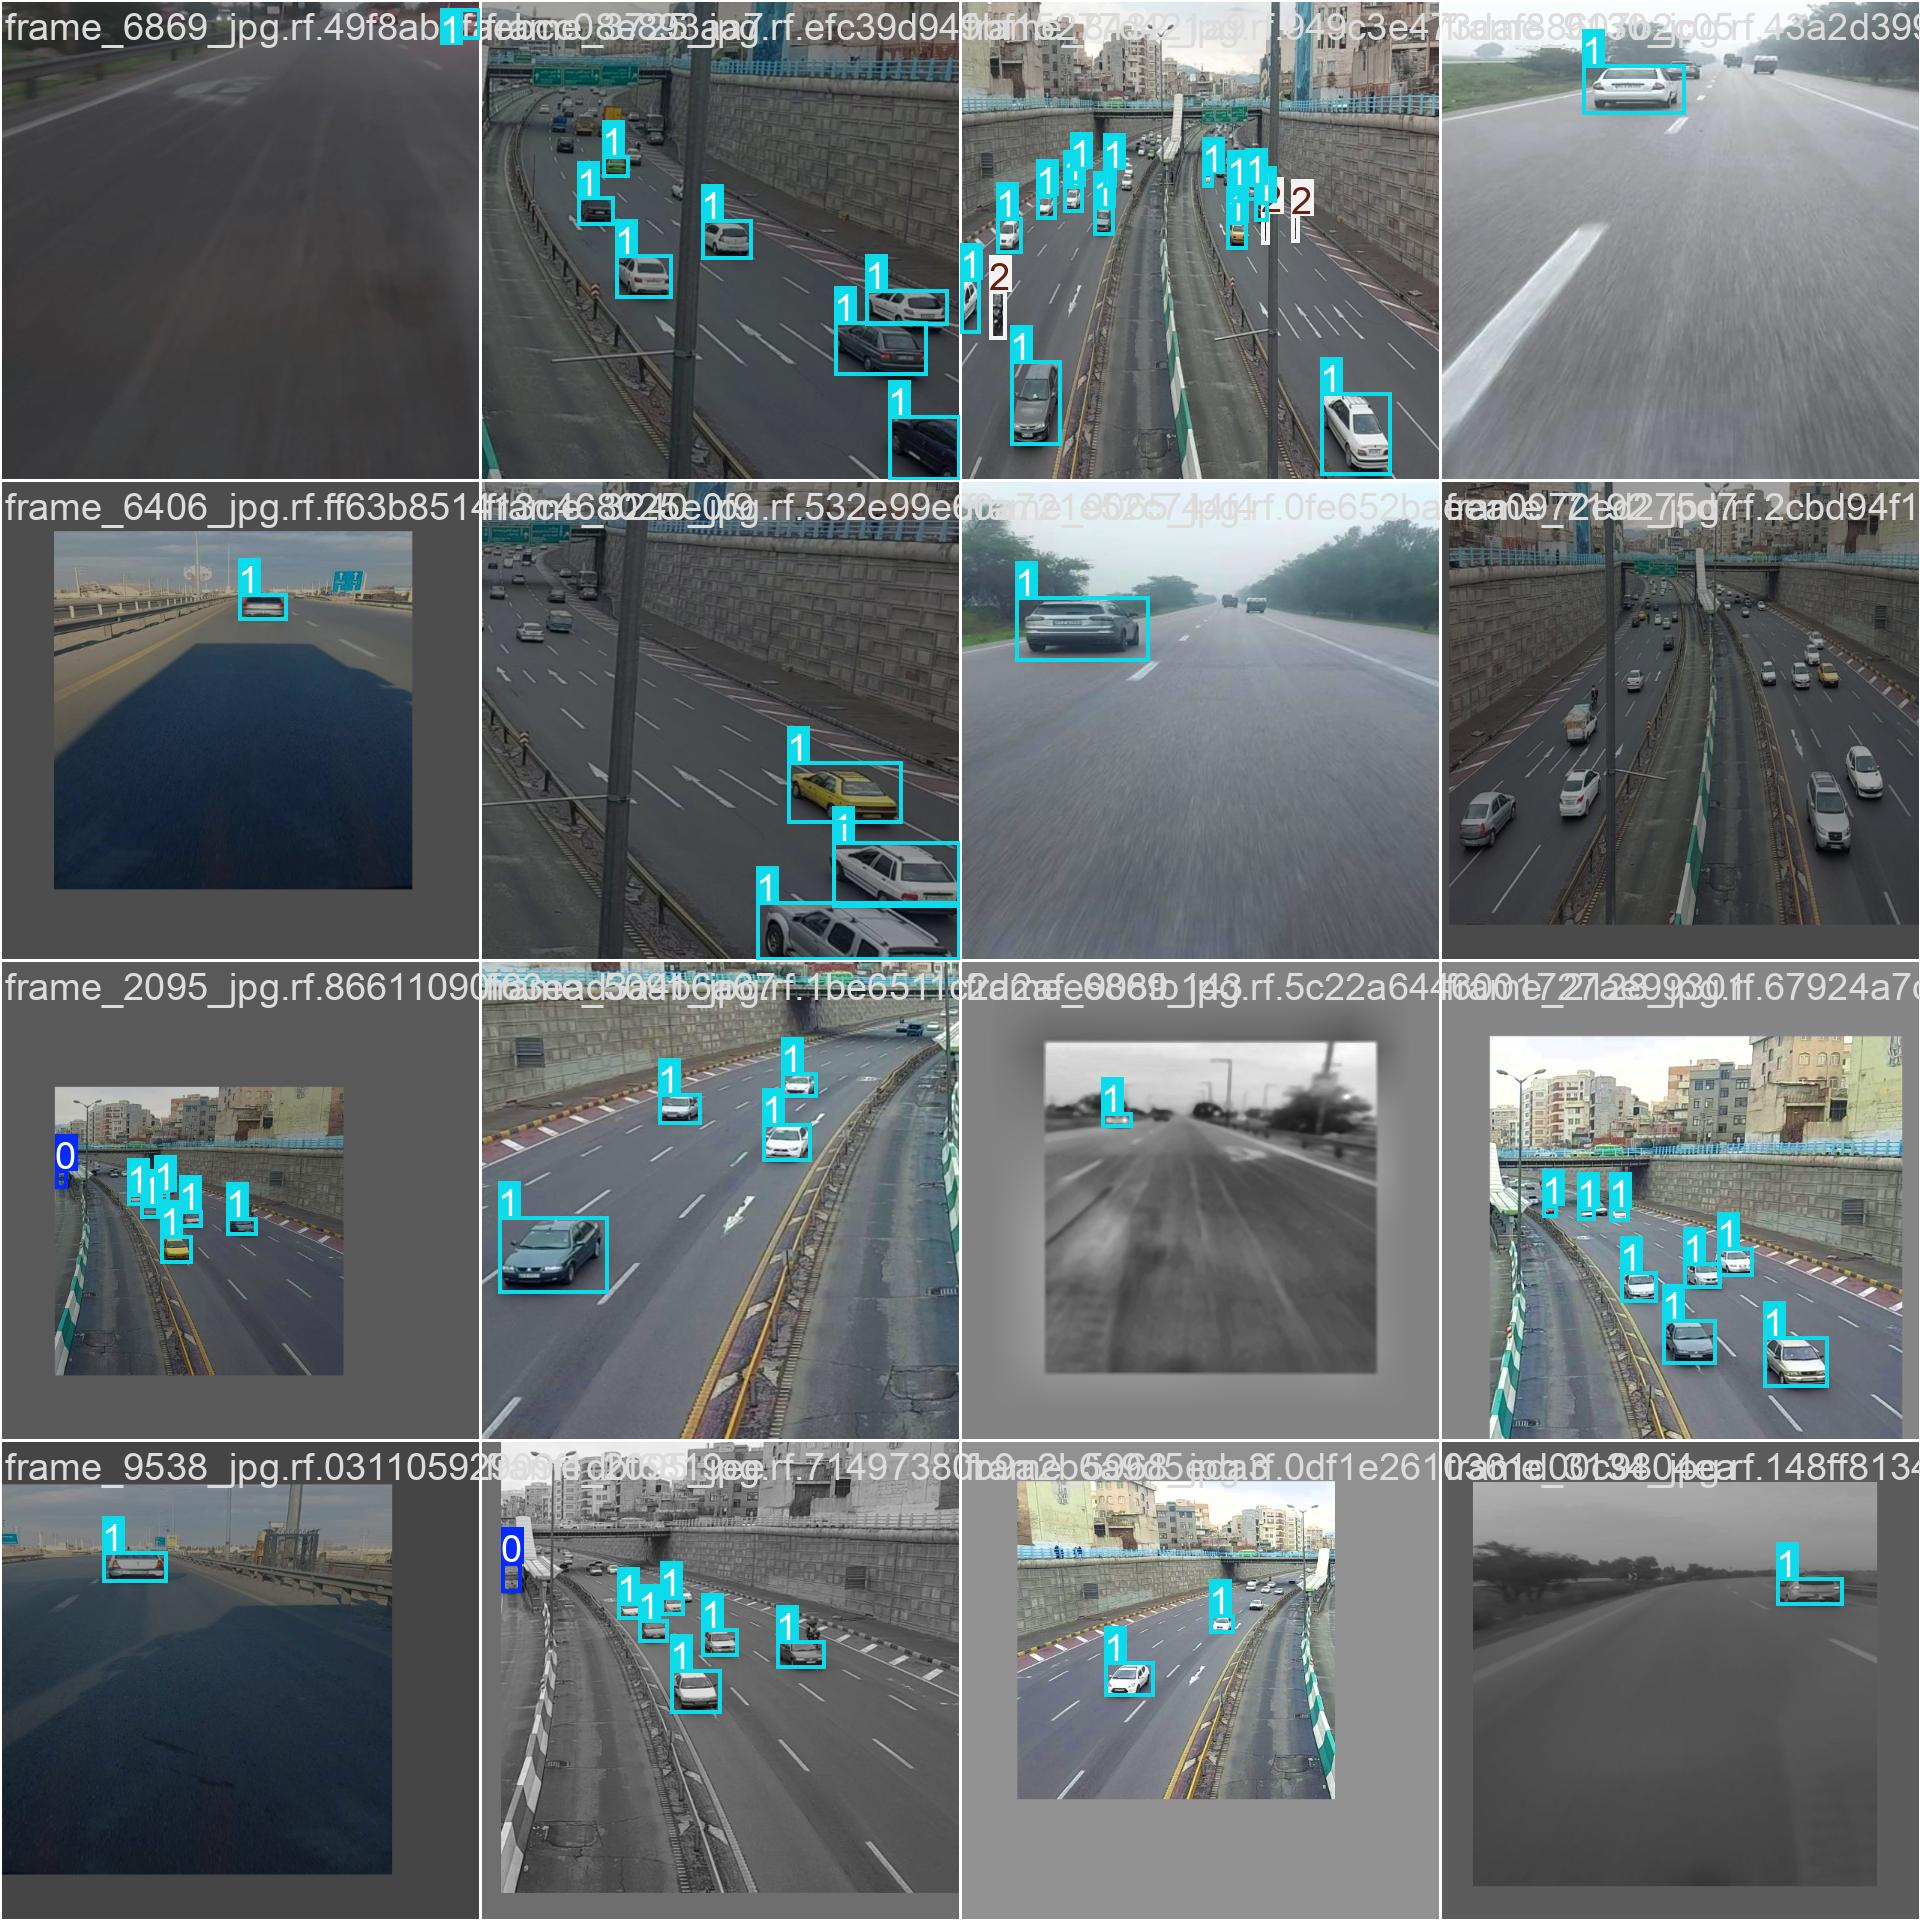

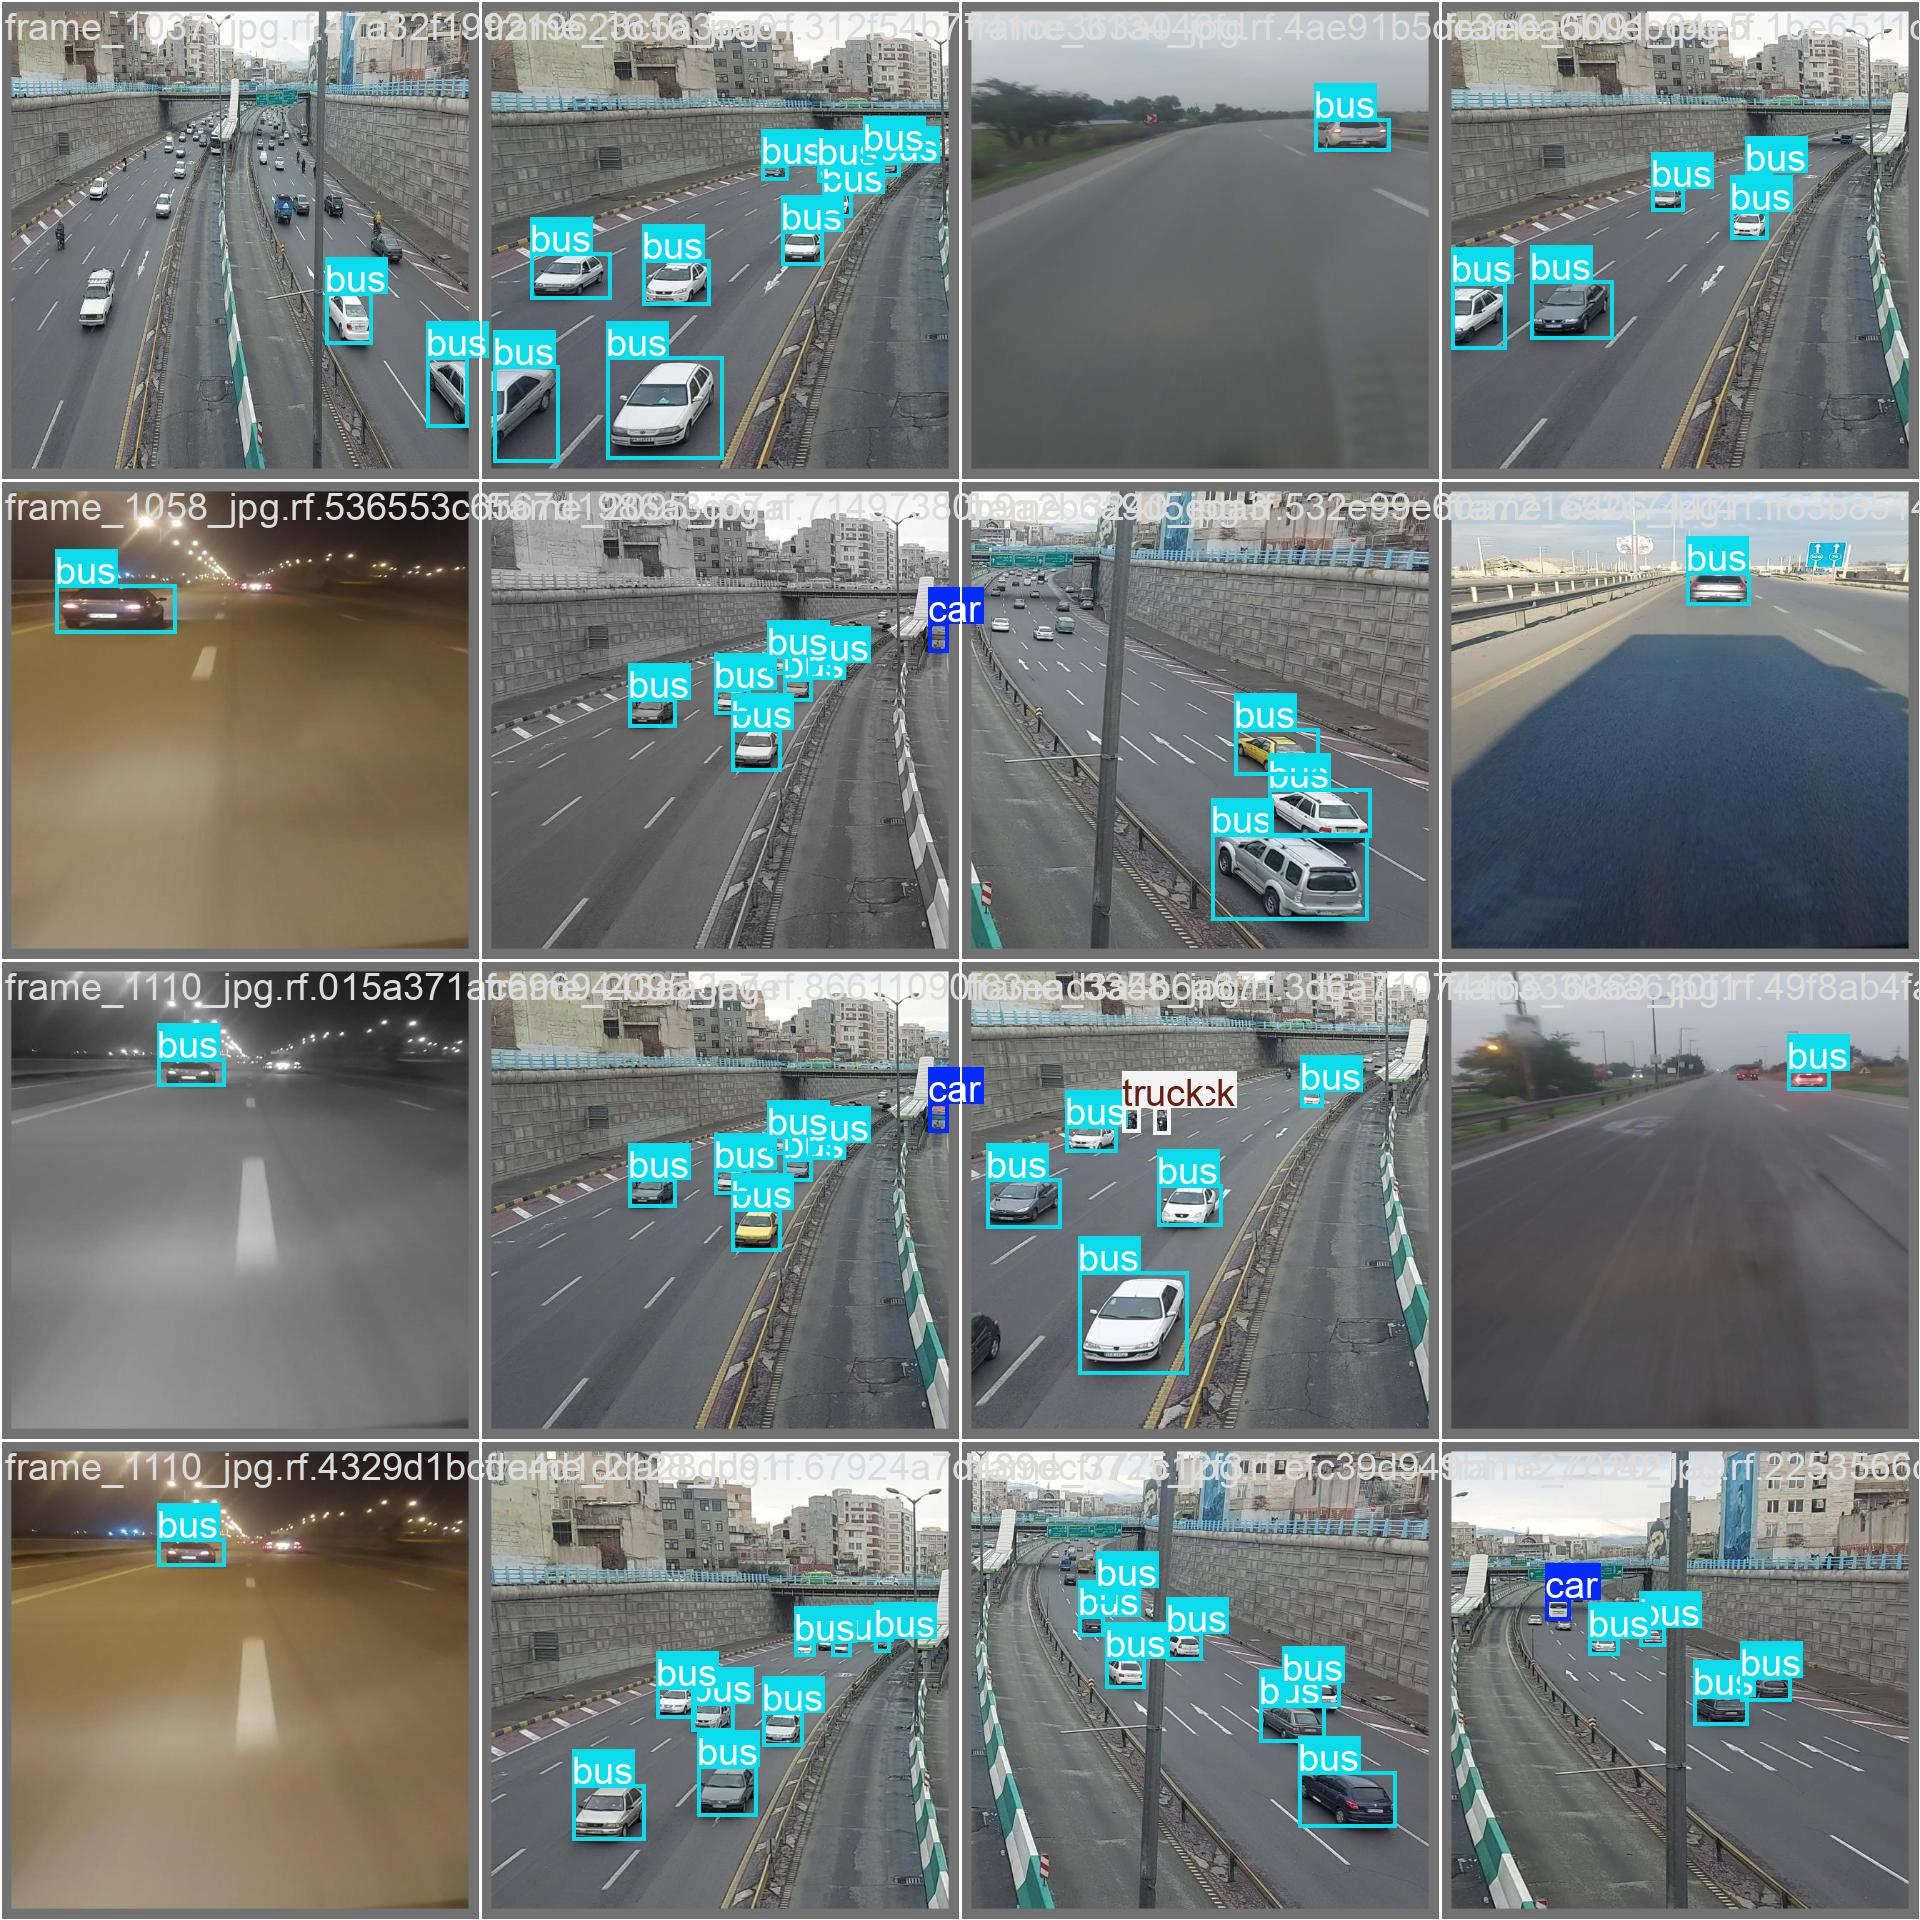

In [ ]:
from IPython.display import Image, display
import glob

pred_images = glob.glob('/content/runs/detect/vehicle_yolov8_project3/*.jpg')
for img_path in pred_images[:5]:  # show top 5
    display(Image(filename=img_path))